## Introduction to Convolutional Neural Networks and Computer Vision

#### Get the data

The images we're working with are from the Food101 dataset (101 different classes of food)
However we've modified it to only use two classes (pizza & steak) using the image data modification notebook

We start with a smaller dataset so we can experiment quickly and figure what works (or better yet what doesn't work before scaling up.)

In [1]:
# import zipfile

# wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# # Unzip the downloaded file
# zip_ref = zipfile.ZipFile("pizza_steak.zip")
# zip_ref.extractall()
# zip_ref.close()

### Inspect the data (become one with it)
A very crucial step at the beginning of any machine learning project is becoming one with the data.

And for a computer vision project... this usually means visualizing many samples of your data.

In [1]:
%ls pizza_steak

 Volume in drive D is New Volume
 Volume Serial Number is 5060-6988

 Directory of d:\DL\TF_ZTM\pizza_steak

25-09-2020  07:26    <DIR>          .
25-09-2020  07:26    <DIR>          ..
20-08-2020  09:51    <DIR>          test
20-08-2020  06:01    <DIR>          train
               0 File(s)              0 bytes
               4 Dir(s)  48,783,032,320 bytes free


In [2]:
%ls "pizza_steak/train/steak"

 Volume in drive D is New Volume
 Volume Serial Number is 5060-6988

 Directory of d:\DL\TF_ZTM\pizza_steak\train\steak

20-08-2020  04:43    <DIR>          .
20-08-2020  04:43    <DIR>          ..
20-09-2019  17:36            36,185 1000205.jpg
20-09-2019  17:36            34,497 100135.jpg
20-09-2019  17:36           116,802 101312.jpg
20-09-2019  17:36            56,754 1021458.jpg
20-09-2019  17:36            34,143 1032846.jpg
20-09-2019  17:36            24,688 10380.jpg
20-09-2019  17:36            37,134 1049459.jpg
20-09-2019  17:36            49,841 1053665.jpg
20-09-2019  17:36            59,983 1068516.jpg
20-09-2019  17:36            28,996 1068975.jpg
20-09-2019  17:36            29,525 1081258.jpg
20-09-2019  17:36            49,577 1090122.jpg
20-09-2019  17:36            59,976 1093966.jpg
20-09-2019  17:36            60,253 1098844.jpg
20-09-2019  17:36            69,843 1100074.jpg
20-09-2019  17:36            45,470 1105280.jpg
20-09-2019  17:36            33,316 11

In [3]:
import os 

# Walk through pizza_steak directory and list number of files
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak\test'.
There are 0 directories and 250 images in 'pizza_steak\test\pizza'.
There are 0 directories and 250 images in 'pizza_steak\test\steak'.
There are 2 directories and 0 images in 'pizza_steak\train'.
There are 0 directories and 750 images in 'pizza_steak\train\pizza'.
There are 0 directories and 750 images in 'pizza_steak\train\steak'.


In [4]:
# Another way to find out how many images are in a file
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))

num_steak_images_train

750

To visualize our images, first let's get the class names programmatically.

In [5]:
# Get the classnames programmatically
import pathlib
import numpy as np
data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # Created a list of class_names from the subdirector
print(class_names)

['pizza' 'steak']


In [4]:
# Let's visualize our images
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
    # Setup the target directory (we'll view images from here)
    target_folder = target_dir+target_class
    
    # Get a random image path
    random_image = random.sample(os.listdir(target_folder), 1)
    print(random_image)
    
    # Read in the image and plot it using matplotlib
    img = mpimg.imread(target_folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off");
    
    print(f"Image shape: {img.shape}") # Show the shape of the image
    
    return img

['1617418.jpg']
Image shape: (512, 512, 3)


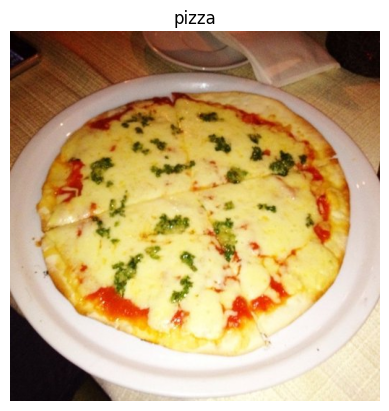

In [7]:
# View a random image from the training dataset
img = view_random_image(target_dir="pizza_steak/train/",
                        target_class="pizza")

In [8]:
# The images we've imported and plotted are actually giant arrays/tensors of different pixel values
import tensorflow as tf
tf.constant(img)

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[ 17,   8,   3],
        [ 18,   9,   4],
        [ 21,  10,   6],
        ...,
        [ 14,   6,   4],
        [ 16,   6,   5],
        [ 17,   7,   6]],

       [[ 14,   5,   0],
        [ 16,   7,   2],
        [ 20,   9,   5],
        ...,
        [ 14,   6,   4],
        [ 17,   7,   6],
        [ 17,   7,   6]],

       [[ 10,   0,   0],
        [ 13,   3,   1],
        [ 17,   7,   5],
        ...,
        [ 14,   6,   4],
        [ 16,   6,   5],
        [ 17,   7,   6]],

       ...,

       [[ 16,  10,  14],
        [ 16,  10,  14],
        [ 16,  10,  14],
        ...,
        [251, 235, 202],
        [255, 236, 204],
        [252, 233, 201]],

       [[ 14,   8,  12],
        [ 15,   9,  13],
        [ 15,   9,  13],
        ...,
        [248, 229, 197],
        [248, 229, 197],
        [246, 227, 195]],

       [[ 12,   6,  10],
        [ 13,   7,  11],
        [ 14,   8,  12],
        ...,
        [245, 226, 19

In [9]:
# View the image shape
img.shape # return width, height. colour channels

(512, 512, 3)

In [10]:
# Get all the pixel values between 0 and 1
img/255.

array([[[0.06666667, 0.03137255, 0.01176471],
        [0.07058824, 0.03529412, 0.01568627],
        [0.08235294, 0.03921569, 0.02352941],
        ...,
        [0.05490196, 0.02352941, 0.01568627],
        [0.0627451 , 0.02352941, 0.01960784],
        [0.06666667, 0.02745098, 0.02352941]],

       [[0.05490196, 0.01960784, 0.        ],
        [0.0627451 , 0.02745098, 0.00784314],
        [0.07843137, 0.03529412, 0.01960784],
        ...,
        [0.05490196, 0.02352941, 0.01568627],
        [0.06666667, 0.02745098, 0.02352941],
        [0.06666667, 0.02745098, 0.02352941]],

       [[0.03921569, 0.        , 0.        ],
        [0.05098039, 0.01176471, 0.00392157],
        [0.06666667, 0.02745098, 0.01960784],
        ...,
        [0.05490196, 0.02352941, 0.01568627],
        [0.0627451 , 0.02352941, 0.01960784],
        [0.06666667, 0.02745098, 0.02352941]],

       ...,

       [[0.0627451 , 0.03921569, 0.05490196],
        [0.0627451 , 0.03921569, 0.05490196],
        [0.0627451 , 0

### An end-to-end example

Let's build a convolutional neural network to find patterns in our images, more specifically we a need way to:

* Load our images
* Preprocess our images
* Build a CNN to find patterns in our images
* Compile our CNN
* Fit the CNN to our training data

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# set the seed
tf.random.set_seed(42)

# Preprocess data (get all of the pixel values between 0 & 1, also called as Scaling/Normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup paths to our data directories
train_dir = "pizza_steak/train"
test_dir = "pizza_steak/test"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                            batch_size=32,
                                            target_size=(224, 224),
                                            class_mode="binary",
                                            seed=42)

valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)

# Build a CNN model (same as the Tiny VGG on the CNN explainer website)
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation="relu",
                           input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding="valid"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.Conv2D(10, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile our CNN
model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_1 = model_1.fit(train_data, 
                        epochs=5, 
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


Epoch 1/5


47/47 [==============================] - 26s 516ms/step - loss: 0.5409 - accuracy: 0.7320 - val_loss: 0.4469 - val_accuracy: 0.8320
Epoch 2/5
47/47 [==============================] - 13s 287ms/step - loss: 0.4170 - accuracy: 0.8127 - val_loss: 0.3882 - val_accuracy: 0.8140
Epoch 3/5
47/47 [==============================] - 13s 284ms/step - loss: 0.3542 - accuracy: 0.8567 - val_loss: 0.3029 - val_accuracy: 0.8680
Epoch 4/5
47/47 [==============================] - 13s 286ms/step - loss: 0.2760 - accuracy: 0.8893 - val_loss: 0.3637 - val_accuracy: 0.8420
Epoch 5/5
47/47 [==============================] - 13s 286ms/step - loss: 0.1981 - accuracy: 0.9313 - val_loss: 0.3599 - val_accuracy: 0.8480


In [12]:
len(train_data)

47

In [13]:
model_1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 10)      280       
                                                                 
 conv2d_1 (Conv2D)           (None, 220, 220, 10)      910       
                                                                 
 max_pooling2d (MaxPooling2  (None, 110, 110, 10)      0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 108, 108, 10)      910       
                                                                 
 conv2d_3 (Conv2D)           (None, 106, 106, 10)      910       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 53, 53, 10)        0         
 g2D)                                                   

## Using the same model as before

Let's replicae the model we've built in a previous section to see if it works with out image data.

In [14]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model to replicate the Tensorflow playground model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the nodel
model_2.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 3. Fit the model
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 [==============================] - 7s 131ms/step - loss: 1.0583 - accuracy: 0.5033 - val_loss: 0.6656 - val_accuracy: 0.5000
Epoch 2/5
47/47 [==============================] - 6s 130ms/step - loss: 0.6805 - accuracy: 0.5187 - val_loss: 0.6804 - val_accuracy: 0.5260
Epoch 3/5
47/47 [==============================] - 6s 117ms/step - loss: 0.6851 - accuracy: 0.5293 - val_loss: 0.6970 - val_accuracy: 0.5000
Epoch 4/5
47/47 [==============================] - 6s 124ms/step - loss: 0.6984 - accuracy: 0.4853 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 5/5
47/47 [==============================] - 6s 117ms/step - loss: 0.6932 - accuracy: 0.4893 - val_loss: 0.6931 - val_accuracy: 0.5000


In [15]:
# Get a summary of model_2
model_2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 150528)            0         
                                                                 
 dense_1 (Dense)             (None, 4)                 602116    
                                                                 
 dense_2 (Dense)             (None, 4)                 20        
                                                                 
 dense_3 (Dense)             (None, 1)                 5         
                                                                 
Total params: 602141 (2.30 MB)
Trainable params: 602141 (2.30 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Despite having 20x more parameters than our CNN (model_1), model_2 performs terribly, let's try to improve it.

In [17]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_3.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 3. Fit the model
history_3 = model_3.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 [==============================] - 14s 286ms/step - loss: 1.7889 - accuracy: 0.6647 - val_loss: 0.6367 - val_accuracy: 0.7700
Epoch 2/5
47/47 [==============================] - 13s 276ms/step - loss: 0.9196 - accuracy: 0.6987 - val_loss: 0.7585 - val_accuracy: 0.6960
Epoch 3/5
47/47 [==============================] - 13s 279ms/step - loss: 1.0204 - accuracy: 0.7040 - val_loss: 0.5851 - val_accuracy: 0.7220
Epoch 4/5
47/47 [==============================] - 13s 277ms/step - loss: 0.5394 - accuracy: 0.7740 - val_loss: 0.7863 - val_accuracy: 0.6380
Epoch 5/5
47/47 [==============================] - 13s 279ms/step - loss: 0.8238 - accuracy: 0.7093 - val_loss: 0.5476 - val_accuracy: 0.7320


In [18]:
# model_3 summary
model_3.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 150528)            0         
                                                                 
 dense_4 (Dense)             (None, 100)               15052900  
                                                                 
 dense_5 (Dense)             (None, 100)               10100     
                                                                 
 dense_6 (Dense)             (None, 100)               10100     
                                                                 
 dense_7 (Dense)             (None, 1)                 101       
                                                                 
Total params: 15073201 (57.50 MB)
Trainable params: 15073201 (57.50 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Binary Classification:

1. Become one with the data (visualize, visualize, visualize)
2. Preprocess the data (prepared it for our  model, the main step here was scaling/normalizing)
3. Created a model (start with a baseline)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and improve the model (try to beat our baseline)
7. Repeat until satisfied (experiment, experiment, experiment)

### 1. Become one with the data

['2125877.jpg']
Image shape: (288, 512, 3)
['3426946.jpg']
Image shape: (512, 512, 3)


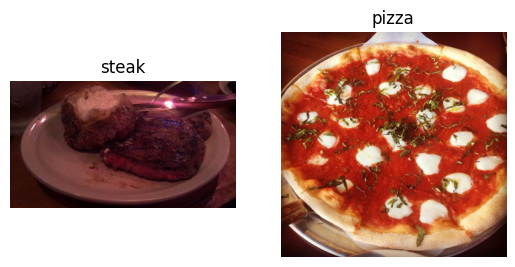

In [16]:
# Visualize data
plt.figure()
plt.subplot(1, 2, 1)
steak_img = view_random_image("pizza_steak/train/", "steak")
plt.subplot(1, 2, 2)
pizza_img = view_random_image("pizza_steak/train/", "pizza")

### 2. Preprocess the data (prepare it for a model)

In [17]:
# Define directory dataset paths
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

Our next step is to turn our data into **batches**

A batch is a small subset of data. Rather than look at all 10000 images at one time , a model might only look at 32 at a time.
It does this for a couple of reasons:
1. 10000 images (or more) might not fit into the memory of your processor (GPU).
2. Trying to learn the patterns in 10000 images in one hit could result in the model not being able to learn very well

In [18]:
!nvidia-smi

Fri Mar  8 22:57:12 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 546.33                 Driver Version: 546.33       CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  | 00000000:01:00.0  On |                  N/A |
| N/A   46C    P8               4W /  30W |    175MiB /  4096MiB |     19%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [19]:
# Create train and test data generators and rescale the data
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

In [20]:
# Load in our image data from directories and turn them into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               batch_size=32)

test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(224, 224),
                                             class_mode="binary",
                                             batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [21]:
# Get a sample of a train data batch
images, labels = train_data.next() 
len(images), len(labels)

(32, 32)

In [22]:
# no of batches
len(train_data)

47

In [23]:
# Get the first two images
images[:2], images[0].shape

(array([[[[0.1137255 , 0.11764707, 0.18823531],
          [0.1137255 , 0.11764707, 0.18823531],
          [0.10980393, 0.1137255 , 0.18431373],
          ...,
          [0.9607844 , 0.9450981 , 0.9490197 ],
          [0.8313726 , 0.81568635, 0.8196079 ],
          [0.9843138 , 0.9686275 , 0.9725491 ]],
 
         [[0.12156864, 0.1254902 , 0.19607845],
          [0.1254902 , 0.12941177, 0.20000002],
          [0.10196079, 0.10588236, 0.1764706 ],
          ...,
          [0.9333334 , 0.92549026, 0.9294118 ],
          [0.909804  , 0.90196085, 0.9058824 ],
          [0.9960785 , 0.98823535, 0.9921569 ]],
 
         [[0.09803922, 0.10196079, 0.17254902],
          [0.10588236, 0.10980393, 0.18039216],
          [0.1254902 , 0.13333334, 0.19215688],
          ...,
          [0.8000001 , 0.79215693, 0.7960785 ],
          [0.909804  , 0.90196085, 0.9058824 ],
          [1.        , 0.9960785 , 1.        ]],
 
         ...,
 
         [[0.09803922, 0.07843138, 0.09411766],
          [0.07843

In [24]:
# View the first batch of labels
labels

array([0., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0.,
       1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0.],
      dtype=float32)

### 3. Create a CNN model (start with a baseline)

In [25]:
# Make the creating of our model a little easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential

In [29]:
# 1.  Create the model (this will be our baseline, a layer convolutional neural network)
model_4 = Sequential([
    Conv2D(filters=10, # Filter is the number of sliding windows going across an input (higher = more complex model)
           kernel_size=3, # the size of the sliding window going across an input 
           strides=1, # the size of the step the sliding window takes across an input 
           padding="valid", # if "same", output 
           activation="relu",
           input_shape=(224, 224, 3)),
    Conv2D(10, 3, activation="relu"),
    Conv2D(10, 3, activation="relu"),
    Flatten(),
    Dense(1, activation="sigmoid") # Output layer (working with binary classification so only 1 output neuron)
])

In [30]:
# 2. Compile the model
model_4.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

In [31]:
# Get a summary of our model
model_4.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 222, 222, 10)      280       
                                                                 
 conv2d_5 (Conv2D)           (None, 220, 220, 10)      910       
                                                                 
 conv2d_6 (Conv2D)           (None, 218, 218, 10)      910       
                                                                 
 flatten_3 (Flatten)         (None, 475240)            0         
                                                                 
 dense_8 (Dense)             (None, 1)                 475241    
                                                                 
Total params: 477341 (1.82 MB)
Trainable params: 477341 (1.82 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### 4. Fit the model

In [32]:
# Check the lengths of training and test data generators
len(train_data), len(test_data)

(47, 16)

In [33]:
# 3. Fit the model 
history_4 = model_4.fit(train_data, # Combination of labels and sample data
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5


47/47 [==============================] - 15s 302ms/step - loss: 0.6351 - accuracy: 0.6820 - val_loss: 0.4803 - val_accuracy: 0.7820
Epoch 2/5
47/47 [==============================] - 14s 289ms/step - loss: 0.4424 - accuracy: 0.8000 - val_loss: 0.3863 - val_accuracy: 0.8460
Epoch 3/5
47/47 [==============================] - 14s 291ms/step - loss: 0.3679 - accuracy: 0.8493 - val_loss: 0.3947 - val_accuracy: 0.8400
Epoch 4/5
47/47 [==============================] - 13s 283ms/step - loss: 0.1950 - accuracy: 0.9393 - val_loss: 0.4284 - val_accuracy: 0.8120
Epoch 5/5
47/47 [==============================] - 14s 290ms/step - loss: 0.0783 - accuracy: 0.9807 - val_loss: 0.5639 - val_accuracy: 0.7820


### 5. Evaluating our model

In [26]:
import pandas as pd
pd.DataFrame(history_4.history).plot(figsize=(10, 7))

NameError: name 'history_4' is not defined

In [11]:
# Plot the validaiton and training curves separately 
def plot_loss_curves(history):
    """
    Returns separate loss curves for training and validation metrics.
    """
    
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    
    epochs= range(len(history.history["loss"]))
    
    # Plot loss
    plt.plot(epochs, loss, label="training_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.title("loss")
    plt.xlabel("epochs")
    plt.legend()
    
    # Plot accuracy 
    plt.figure()
    plt.plot(epochs, accuracy, label="training_accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.title("accuracy")
    plt.xlabel("epochs")
    plt.legend()

**Note:** When a model's **validation loss starts to increase**, it's likely that the model is **overfitting** the training dataset. This means , it's learning the patterns in the training dataset *too well* and thus the model's ability to generalize to unseen data will be diminished.

In [28]:
# Check out the loss and accuracy of model_4
plot_loss_curves(history_4)

NameError: name 'history_4' is not defined

### 6. Adjust the model parameter
Fitting a machine learning model comes in 3 steps:

0. Create a baseline
1. Beat the baseline by overfitting a larger model
2. Reduce overfitting

Ways to induce overfitting:

* Increase the number of conv layers
* Increase the number of conv filters
* Add another dense layer to the output of our flattened layer

Reduce overfitting:
* Add data augmentation
* Add regularization layers (such as MaxPool2D)
* Add more data..

In [ ]:
# 1. Create the model (this is going to be our new baseline)
model_5 = Sequential([
    Conv2D(10, 3, activation="relu", input_shape=(224, 224, 3)),
    MaxPool2D(pool_size=2),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

In [ ]:
# 2. Compile the model
model_5.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

In [ ]:
# 3. Fit the model
history_5 = model_5.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 [==============================] - 10s 205ms/step - loss: 0.6490 - accuracy: 0.6067 - val_loss: 0.5469 - val_accuracy: 0.7200
Epoch 2/5
47/47 [==============================] - 10s 208ms/step - loss: 0.5103 - accuracy: 0.7547 - val_loss: 0.4168 - val_accuracy: 0.8260
Epoch 3/5
47/47 [==============================] - 9s 197ms/step - loss: 0.4356 - accuracy: 0.8007 - val_loss: 0.3936 - val_accuracy: 0.8360
Epoch 4/5
47/47 [==============================] - 9s 193ms/step - loss: 0.4121 - accuracy: 0.8180 - val_loss: 0.3569 - val_accuracy: 0.8340
Epoch 5/5
47/47 [==============================] - 9s 182ms/step - loss: 0.3881 - accuracy: 0.8340 - val_loss: 0.3423 - val_accuracy: 0.8500


In [ ]:
# Get the summary of our model with max pooling 
model_5.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 222, 222, 10)      280       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 111, 111, 10)      0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 109, 109, 10)      910       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 54, 54, 10)        0         
 g2D)                                                            
                                                                 
 conv2d_9 (Conv2D)           (None, 52, 52, 10)        910       
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 26, 26, 10)       

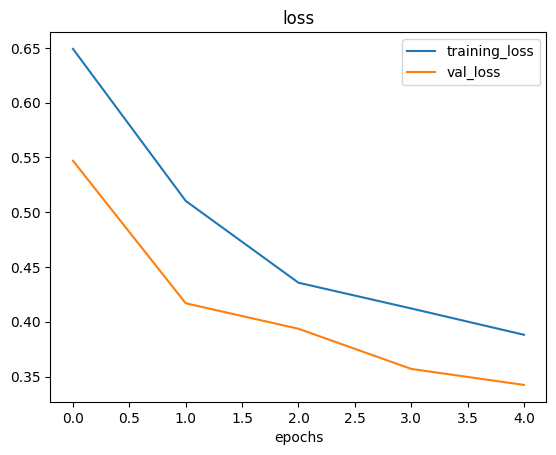

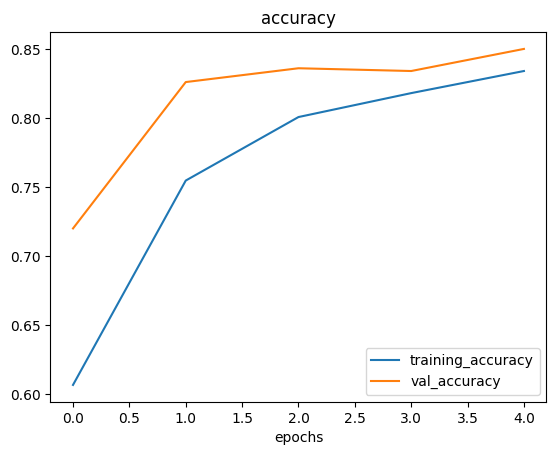

In [ ]:
# Plot history curves
plot_loss_curves(history_5)

### Opening our bag of tricks and finding data augmentation

In [29]:
# Create ImageDataGenerator training instance with data augmentation
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=0.2,
                                             shear_range=0.2,
                                             zoom_range=0.2,
                                             width_shift_range=0.2,
                                             height_shift_range=0.3,
                                             horizontal_flip=True)

#  Create ImageDataGenerator without data augmentation
train_datagen = ImageDataGenerator(rescale=1/255.)

# Create ImageDataGenerator without data augmentation for the test dataset
test_datagen = ImageDataGenerator(rescale=1/255.)


In [30]:
# Setting image size 
IMG_SIZE = (224, 224)

# Import data and augment it from training directory
print("Augmented training data:")
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=IMG_SIZE,
                                                                   batch_size=32,
                                                                   class_mode="binary",
                                                                   shuffle=False) # For demonstration purposes only

# Create non-augmented train data batches
print("Non-augmented training data:")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=IMG_SIZE,
                                               batch_size=32,
                                               class_mode="binary",
                                               shuffle=False)

# Create non-augmented test data  batches
print("Non-augmented test data:")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=IMG_SIZE,
                                             batch_size=32,
                                             class_mode="binary")

Augmented training data:
Found 1500 images belonging to 2 classes.
Non-augmented training data:
Found 1500 images belonging to 2 classes.


Non-augmented test data:
Found 500 images belonging to 2 classes.


In [31]:
# Get sample data batches
images, labels = train_data.next()
augmented_images, augmented_labels = train_data_augmented.next()

showing image number:  6


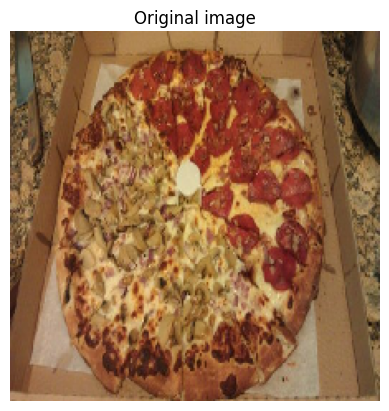

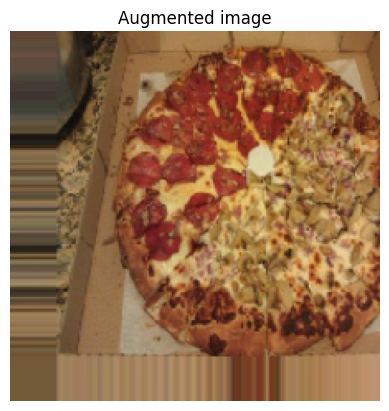

In [32]:
# Show original image and augmented image
import random
random_number = random.randint(0, 31) # our batch sizes are 32
print(f"showing image number:  {random_number}")
plt.imshow(images[random_number])
plt.title(f"Original image")
plt.axis(False)
plt.figure()
plt.imshow(augmented_images[random_number])
plt.title(f"Augmented image")
plt.axis(False);

Let's build a model and see how it learns on augmented data

In [46]:
# 1. Create a model (same as model_5)
model_6 = Sequential([
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(pool_size=2),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_6.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

# 3. Fit the model
history_6 = model_6.fit(train_data_augmented,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 [==============================] - 20s 407ms/step - loss: 0.7149 - accuracy: 0.4447 - val_loss: 0.6839 - val_accuracy: 0.5320
Epoch 2/5
47/47 [==============================] - 19s 396ms/step - loss: 0.7059 - accuracy: 0.5660 - val_loss: 0.6810 - val_accuracy: 0.5260
Epoch 3/5
47/47 [==============================] - 20s 432ms/step - loss: 0.6938 - accuracy: 0.5133 - val_loss: 0.6743 - val_accuracy: 0.5000
Epoch 4/5
47/47 [==============================] - 20s 435ms/step - loss: 0.6835 - accuracy: 0.5280 - val_loss: 0.6554 - val_accuracy: 0.5140
Epoch 5/5
47/47 [==============================] - 19s 410ms/step - loss: 0.6978 - accuracy: 0.5513 - val_loss: 0.6646 - val_accuracy: 0.5720


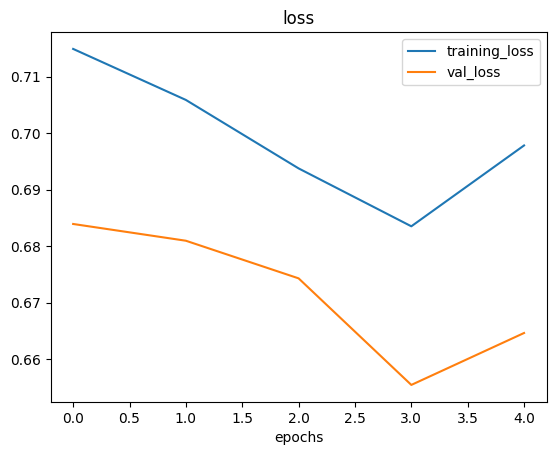

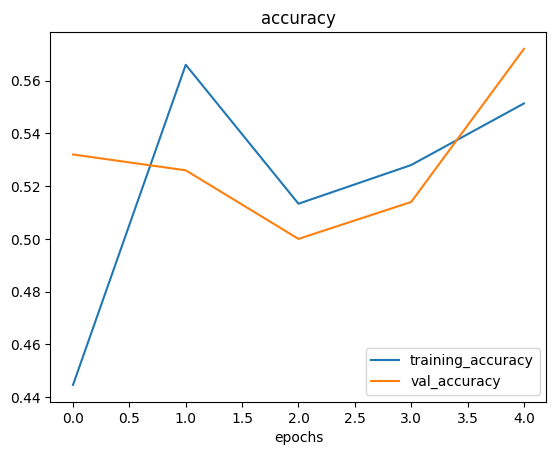

In [47]:
# check our model training curves
plot_loss_curves(history_6)

Let's shuffle our augmented training data and train another model on it and see what happens.

In [33]:
# Import data and augment it and shuffle from training directory
train_data_augmented_shuffled = train_datagen_augmented.flow_from_directory(train_dir,
                                                                            target_size=IMG_SIZE,
                                                                            class_mode="binary",
                                                                            batch_size=32,
                                                                            shuffle=True) # Shuffle dat athis time

Found 1500 images belonging to 2 classes.


In [38]:
# 1. Create the model (same as model_5 and model_6)
model_7 = Sequential([
    Conv2D(10, 3, activation="relu", input_shape=(224, 224, 3)),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_7.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

# 3. Fit the model
history_7 = model_7.fit(train_data_augmented_shuffled, # we're fitting on augmented and shuffled data now
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 [==============================] - 23s 473ms/step - loss: 0.6782 - accuracy: 0.5600 - val_loss: 0.6042 - val_accuracy: 0.6880
Epoch 2/5
47/47 [==============================] - 22s 460ms/step - loss: 0.5736 - accuracy: 0.7100 - val_loss: 0.4236 - val_accuracy: 0.7980
Epoch 3/5
47/47 [==============================] - 21s 449ms/step - loss: 0.5364 - accuracy: 0.7307 - val_loss: 0.3904 - val_accuracy: 0.8340
Epoch 4/5
47/47 [==============================] - 21s 439ms/step - loss: 0.5121 - accuracy: 0.7507 - val_loss: 0.3717 - val_accuracy: 0.8460
Epoch 5/5
47/47 [==============================] - 20s 421ms/step - loss: 0.4830 - accuracy: 0.7680 - val_loss: 0.3703 - val_accuracy: 0.8160


### 7. Repeat until satified

Since we've already beaten our baseline, there are a few things we could try to continue to improve our model:

* Increase the number of model layers (e.g. add more `Conv2D`/`MaxPool2D` layers)
* Increase the number of filters in each convolutional layer 
* Train for longer (more epochs)
* Find an ideal learning rate
* Get more data 
* Ues transfer learning to leverage what another image model has learn and adjust it for our own use case


In [50]:
# 1. Create the model (try to add more layers)
model_8 = Sequential([
    Conv2D(10, 3, activation="relu", input_shape=(224, 224, 3)),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_8.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

# 3. Fit the model
history_8 = model_8.fit(train_data_augmented_shuffled, # we're fitting on augmented and shuffled data now
                        epochs=10,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/10
47/47 [==============================] - 21s 430ms/step - loss: 0.6527 - accuracy: 0.6133 - val_loss: 0.5526 - val_accuracy: 0.7060
Epoch 2/10
47/47 [==============================] - 19s 407ms/step - loss: 0.5498 - accuracy: 0.7260 - val_loss: 0.4054 - val_accuracy: 0.8300
Epoch 3/10
47/47 [==============================] - 19s 399ms/step - loss: 0.5215 - accuracy: 0.7480 - val_loss: 0.4309 - val_accuracy: 0.7980
Epoch 4/10
47/47 [==============================] - 19s 398ms/step - loss: 0.5140 - accuracy: 0.7400 - val_loss: 0.3801 - val_accuracy: 0.8380
Epoch 5/10
47/47 [==============================] - 19s 395ms/step - loss: 0.4806 - accuracy: 0.7753 - val_loss: 0.3625 - val_accuracy: 0.8280
Epoch 6/10
47/47 [==============================] - 19s 402ms/step - loss: 0.4798 - accuracy: 0.7753 - val_loss: 0.3479 - val_accuracy: 0.8700
Epoch 7/10
47/47 [==============================] - 20s 435ms/step - loss: 0.4706 - accuracy: 0.7867 - val_loss: 0.3247 - val_accuracy: 0.8620

In [51]:
# 1. Create the model (try to increase filters in Conv layers)
model_9 = Sequential([
    Conv2D(64, 3, activation="relu", input_shape=(224, 224, 3)),
    MaxPool2D(),
    Conv2D(64, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(64, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_9.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

# 3. Fit the model
history_9 = model_9.fit(train_data_augmented_shuffled, # we're fitting on augmented and shuffled data now
                        epochs=10,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/10
47/47 [==============================] - 96s 2s/step - loss: 0.6317 - accuracy: 0.6407 - val_loss: 0.4922 - val_accuracy: 0.7520
Epoch 2/10
47/47 [==============================] - 72s 2s/step - loss: 0.5542 - accuracy: 0.7147 - val_loss: 0.3899 - val_accuracy: 0.8300
Epoch 3/10
47/47 [==============================] - 73s 2s/step - loss: 0.4818 - accuracy: 0.7687 - val_loss: 0.3380 - val_accuracy: 0.8680
Epoch 4/10
47/47 [==============================] - 74s 2s/step - loss: 0.4836 - accuracy: 0.7807 - val_loss: 0.3530 - val_accuracy: 0.8700
Epoch 5/10
47/47 [==============================] - 65s 1s/step - loss: 0.4512 - accuracy: 0.8033 - val_loss: 0.3432 - val_accuracy: 0.8620
Epoch 6/10
47/47 [==============================] - 61s 1s/step - loss: 0.4628 - accuracy: 0.7847 - val_loss: 0.2987 - val_accuracy: 0.8780
Epoch 7/10
47/47 [==============================] - 66s 1s/step - loss: 0.4406 - accuracy: 0.8033 - val_loss: 0.3016 - val_accuracy: 0.8760
Epoch 8/10
47/47 [==

In [52]:
# 1. Create the model (increasing no of epochs)
model_10 = Sequential([
    Conv2D(64, 3, activation="relu", input_shape=(224, 224, 3)),
    MaxPool2D(),
    Conv2D(64, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(64, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_10.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

# 3. Fit the model
history_10 = model_10.fit(train_data_augmented_shuffled, # we're fitting on augmented and shuffled data now
                        epochs=15,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/15
47/47 [==============================] - 60s 1s/step - loss: 0.6935 - accuracy: 0.5653 - val_loss: 0.6066 - val_accuracy: 0.7180
Epoch 2/15
47/47 [==============================] - 92s 2s/step - loss: 0.5569 - accuracy: 0.7060 - val_loss: 0.4208 - val_accuracy: 0.8200
Epoch 3/15
47/47 [==============================] - 59s 1s/step - loss: 0.5016 - accuracy: 0.7667 - val_loss: 0.3803 - val_accuracy: 0.8440
Epoch 4/15
47/47 [==============================] - 63s 1s/step - loss: 0.5094 - accuracy: 0.7653 - val_loss: 0.3269 - val_accuracy: 0.8760
Epoch 5/15
47/47 [==============================] - 61s 1s/step - loss: 0.5034 - accuracy: 0.7520 - val_loss: 0.3710 - val_accuracy: 0.8480
Epoch 6/15
47/47 [==============================] - 60s 1s/step - loss: 0.4747 - accuracy: 0.7840 - val_loss: 0.3399 - val_accuracy: 0.8760
Epoch 7/15
47/47 [==============================] - 59s 1s/step - loss: 0.4679 - accuracy: 0.7967 - val_loss: 0.3539 - val_accuracy: 0.8520
Epoch 8/15
47/47 [==

In [53]:
# Try agin with 25 epochs
# 1. Create the model (increasing no of epochs)
model_11 = Sequential([
    Conv2D(64, 3, activation="relu", input_shape=(224, 224, 3)),
    MaxPool2D(),
    Conv2D(64, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(64, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_11.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

# 3. Fit the model
history_11 = model_11.fit(train_data_augmented_shuffled, # we're fitting on augmented and shuffled data now
                        epochs=25,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/25
47/47 [==============================] - 62s 1s/step - loss: 0.6983 - accuracy: 0.5300 - val_loss: 0.6077 - val_accuracy: 0.7800
Epoch 2/25
47/47 [==============================] - 59s 1s/step - loss: 0.5732 - accuracy: 0.7187 - val_loss: 0.4743 - val_accuracy: 0.7700
Epoch 3/25
47/47 [==============================] - 59s 1s/step - loss: 0.5113 - accuracy: 0.7660 - val_loss: 0.3807 - val_accuracy: 0.8320
Epoch 4/25
47/47 [==============================] - 99s 2s/step - loss: 0.4776 - accuracy: 0.7813 - val_loss: 0.3639 - val_accuracy: 0.8560
Epoch 5/25
47/47 [==============================] - 57s 1s/step - loss: 0.4960 - accuracy: 0.7580 - val_loss: 0.3517 - val_accuracy: 0.8800
Epoch 6/25
47/47 [==============================] - 56s 1s/step - loss: 0.4474 - accuracy: 0.7980 - val_loss: 0.5451 - val_accuracy: 0.7940
Epoch 7/25
47/47 [==============================] - 56s 1s/step - loss: 0.4773 - accuracy: 0.7873 - val_loss: 0.4325 - val_accuracy: 0.8200
Epoch 8/25
47/47 [==

In [34]:
# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=224):
    """
    Reads an image from filename, turns it into a tensor and reshapes it to (img_shape, img_shape., colour_channels).
    """
    # Read in the image
    img = tf.io.read_file(filename)
    # Decode read file into a tensor
    img = tf.image.decode_image(img)
    # Resize the image
    img = tf.image.resize(img, size=[img_shape, img_shape])
    # Rescale the image (gell all values between 0 and 1)
    img = img/255. 
    return img

In [35]:
# Load in and preprocess our custom images
steak = load_and_prep_image("pizza_steak/test/pizza/11297.jpg")
steak

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.32778546, 0.29249135, 0.23366785],
        [0.33384103, 0.2985469 , 0.23972338],
        [0.34725142, 0.3119573 , 0.25313377],
        ...,
        [0.42384517, 0.31404126, 0.26698244],
        [0.41890442, 0.30910048, 0.2657094 ],
        [0.40581918, 0.29601523, 0.25287798]],

       [[0.32061136, 0.28531724, 0.22649372],
        [0.3335872 , 0.29829308, 0.23946954],
        [0.33747187, 0.30217776, 0.24335422],
        ...,
        [0.4392157 , 0.32941177, 0.28235295],
        [0.4279505 , 0.3181466 , 0.27108777],
        [0.41540617, 0.30560225, 0.25854343]],

       [[0.33611697, 0.30082282, 0.2419993 ],
        [0.34812486, 0.31283075, 0.25400722],
        [0.34430146, 0.30900735, 0.25018382],
        ...,
        [0.41554067, 0.3093752 , 0.25442943],
        [0.42028502, 0.3200593 , 0.26941156],
        [0.41295716, 0.31655398, 0.26502222]],

       ...,

       [[0.64517486, 0.6765474 , 0.82561135],
        [0.58

In [36]:
pred = model_7.predict(tf.expand_dims(steak, axis=0))
pred

NameError: name 'model_7' is not defined

Looks like our custom image is being put through our model, however, it currently outputs a prediction probability so we are visualizing image as well as model prediction

In [ ]:
# Remind ourselves of our class names
class_names

array(['pizza', 'steak'], dtype='<U5')

In [ ]:
# We can index the predicted class by rounding the prediction probability and indexing it on the class names
pred_class = class_names[int(tf.round(pred))]
pred_class

'pizza'

In [37]:
# function for prediction and plotting
def pred_and_plot(model, filename, class_names=class_names):
    """
    Imports and image located at filename, makes a prediction with model 
    and plots the image with the predicted class as the title.
    """
    # Import the target image and preprocess it
    img = load_and_prep_image(filename)
    
    # make a prediciton
    pred = model.predict(tf.expand_dims(img, axis=0))
    
    # Get the predicted class
    pred_class = class_names[int(tf.round(pred))]
    
    # plot the image and predicted class
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis(False);

1/1 [==============================] - 0s 36ms/step


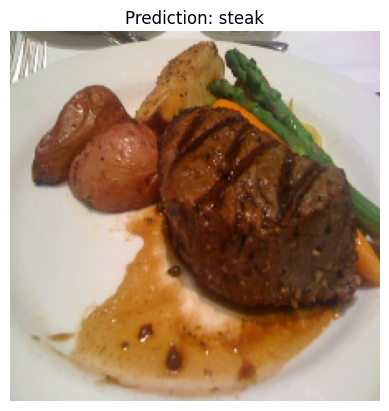

In [ ]:
# Test our model on a custom iamge
pred_and_plot(model_7, "pizza_steak/test/steak/66183.jpg")

# Multi-class Image Classification

We've just been through a bunch of the following steps with a binary classification problem (pizza vs steak), now we're going to step things up a notch with 10 classes of food (multi-class classification).

1. Become one with the data.
2. Preprocess the data (get it ready for a model)
3. Create a model (start with a baseline)
4. Fit the model (overfit it to make sure it works)
5. Evaluate the model
6. Adjust different hyperparameters and imrprove the model (try to beat the baseline/reduce overfitting)
7. Repeat until satisfied

### Import and become one with the data

In [3]:
# # Import and become one with the data

# import zipfile

# !wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

# # Unzip our data
# zip_ref = zipfile.ZipFile("10_food_classes_all_data.zip", "r")
# zip_ref.extractall()
# zip_ref.close()

In [1]:
import os

# Walk through 10 classes of food image data
for dirpath, dirnames, filenames in os.walk("10_food_classes_all_data"):
    print(f"There are {len(dirnames)} directories and  {len(filenames)} images in '{dirpath}'.")

There are 2 directories and  0 images in '10_food_classes_all_data'.
There are 10 directories and  0 images in '10_food_classes_all_data\test'.
There are 0 directories and  250 images in '10_food_classes_all_data\test\chicken_curry'.
There are 0 directories and  250 images in '10_food_classes_all_data\test\chicken_wings'.
There are 0 directories and  250 images in '10_food_classes_all_data\test\fried_rice'.
There are 0 directories and  250 images in '10_food_classes_all_data\test\grilled_salmon'.
There are 0 directories and  250 images in '10_food_classes_all_data\test\hamburger'.
There are 0 directories and  250 images in '10_food_classes_all_data\test\ice_cream'.
There are 0 directories and  250 images in '10_food_classes_all_data\test\pizza'.
There are 0 directories and  250 images in '10_food_classes_all_data\test\ramen'.
There are 0 directories and  250 images in '10_food_classes_all_data\test\steak'.
There are 0 directories and  250 images in '10_food_classes_all_data\test\sushi'

In [1]:
# Setup the train and test directories
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"

In [2]:
# let's get the class names
import pathlib
import numpy as np
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


In [5]:
# Visualize, visualize , visualize
import random
img = view_random_image(target_dir=train_dir,
                        target_class=random.choice(class_names))

NameError: name 'os' is not defined

### 2. Preprocess the data (prepare it for a model)

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescale 
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

# Load data in from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode="categorical")

test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(224, 224),
                                             batch_size=32,
                                             class_mode="categorical")


Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


### 3. Create a model (start with a baseline)

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Activation

# 1. Create our model (very similar to previous models but actually the same as CNN explainer website)
model_12 = Sequential([
    Conv2D(10, 3, input_shape=(224, 224, 3)),
    Activation(activation="relu"),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation="softmax") # changed to have 10 output neurons and use the the softmax activation function
])

# 2. Compile the model
model_12.compile(loss="categorical_crossentropy",
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

### 4. Fit a model

In [8]:
# 3. Fit the model
history_12 = model_12.fit(train_data, # 10 classes
                          epochs=5,
                          steps_per_epoch=len(train_data),
                          validation_data=test_data,
                          validation_steps=len(test_data))

Epoch 1/5


235/235 [==============================] - 118s 498ms/step - loss: 2.1424 - accuracy: 0.2171 - val_loss: 2.0294 - val_accuracy: 0.2844
Epoch 2/5
235/235 [==============================] - 60s 256ms/step - loss: 1.9064 - accuracy: 0.3235 - val_loss: 1.8534 - val_accuracy: 0.3508
Epoch 3/5
235/235 [==============================] - 60s 257ms/step - loss: 1.6415 - accuracy: 0.4424 - val_loss: 1.8608 - val_accuracy: 0.3552
Epoch 4/5
235/235 [==============================] - 75s 319ms/step - loss: 1.1971 - accuracy: 0.6073 - val_loss: 2.1458 - val_accuracy: 0.3204
Epoch 5/5
235/235 [==============================] - 66s 280ms/step - loss: 0.6030 - accuracy: 0.8045 - val_loss: 2.7184 - val_accuracy: 0.2812


### 5. Evaluate the model

In [9]:
# Evaluate one the test data
model_12.evaluate(test_data)

79/79 [==============================] - 10s 121ms/step - loss: 2.7184 - accuracy: 0.2812


[2.7184159755706787, 0.28119999170303345]

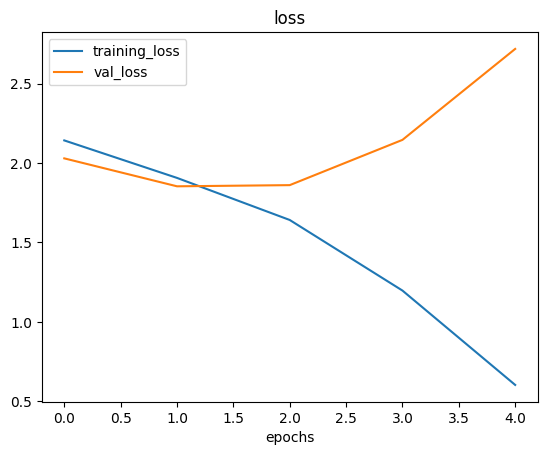

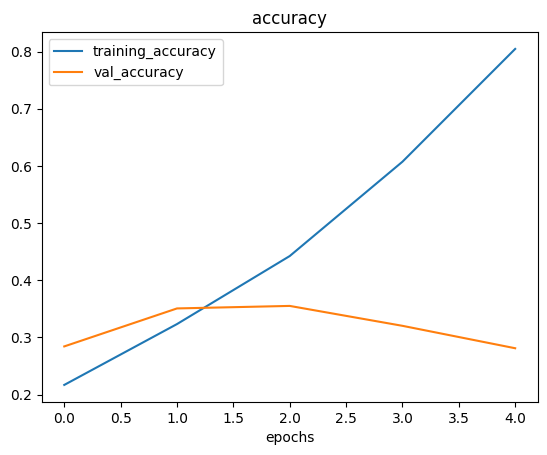

In [12]:
# Check out the model's loss curves on the 10 classes
plot_loss_curves(history_12)

### 6. Adjust the model hyperparameters (to beat the baseline/reduce overfitting)

In [ ]:
model_12.summary()

In [13]:
# let's try to remove 2 convolution layers..
model_13 = Sequential([
    Conv2D(10, 3, activation="relu", input_shape=(224, 224, 3)),
    MaxPool2D(),
    Conv2D(10, 3, activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation="softmax")
])

model_13.compile(loss="categorical_crossentropy",
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

In [14]:
model_13.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 222, 222, 10)      280       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 111, 111, 10)      0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 109, 109, 10)      910       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 54, 54, 10)        0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 29160)             0         
                                                                 
 dense_1 (Dense)             (None, 10)               

In [15]:
# Fit the model with 2x conv layers removed
history_13 = model_13.fit(train_data,
                          epochs=5,
                          steps_per_epoch=len(train_data),
                          validation_data=test_data,
                          validation_steps=len(test_data))

Epoch 1/5
235/235 [==============================] - 47s 198ms/step - loss: 2.1685 - accuracy: 0.2161 - val_loss: 2.0385 - val_accuracy: 0.2588
Epoch 2/5
235/235 [==============================] - 42s 180ms/step - loss: 1.8433 - accuracy: 0.3660 - val_loss: 1.8929 - val_accuracy: 0.3540
Epoch 3/5
235/235 [==============================] - 42s 181ms/step - loss: 1.5259 - accuracy: 0.4928 - val_loss: 1.8653 - val_accuracy: 0.3624
Epoch 4/5
235/235 [==============================] - 42s 180ms/step - loss: 1.1146 - accuracy: 0.6463 - val_loss: 2.1340 - val_accuracy: 0.3176
Epoch 5/5
235/235 [==============================] - 43s 182ms/step - loss: 0.6576 - accuracy: 0.8069 - val_loss: 2.3848 - val_accuracy: 0.3136


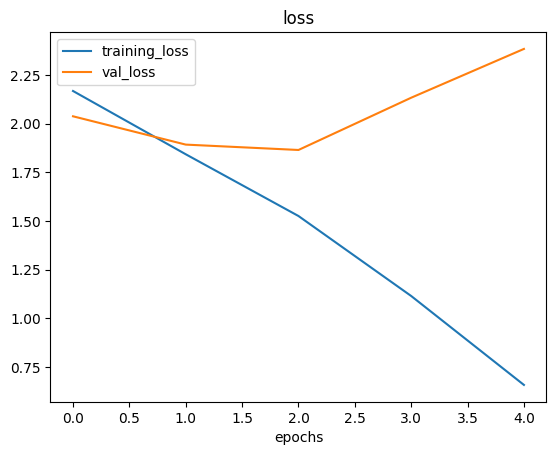

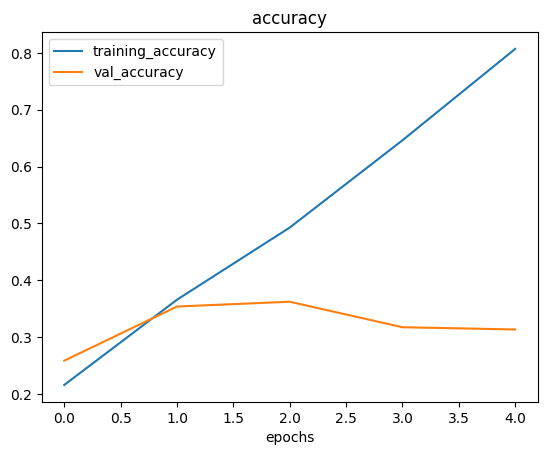

In [16]:
# Checking out the loss curves
plot_loss_curves(history_13)